In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving whatsapp_classification_dataset_10000.csv to whatsapp_classification_dataset_10000.csv


In [2]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

,name,number,isadmin,timestamp,group_name,message_data,word_count,has_placement,has_exam,has_deadline,has_event,category,sentiment_score,urgency_score
0,Priya,1,1,2026-05-19 09:00:00,AI Club,No classes on Friday due to maintenance,7,0,0,0,0,holiday_notice,0.18,9.8
1,Divya,2,1,2026-05-19 09:07:00,CSE Internal Tests,Mock interview scheduled for today evening,6,1,0,0,0,placement_test,0.13,6.7
2,Priya,3,1,2026-05-19 09:14:00,Final Year Projects,No classes on Friday due to maintenance,7,0,0,0,0,holiday_notice,0.84,7.9
3,Rohit,4,1,2026-05-19 09:21:00,CSE Assignments,CN internal exam on Wednesday,5,0,1,0,0,exam_notification,0.15,5.9
4,Rahul,5,0,2026-05-19 09:28:00,CSE Placement Updates,Wipro interview shortlist released,4,1,0,0,0,placement_test,0.47,5.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             10000 non-null  object 
 1   number           10000 non-null  int64  
 2   isadmin          10000 non-null  int64  
 3   timestamp        10000 non-null  object 
 4   group_name       10000 non-null  object 
 5   message_data     10000 non-null  object 
 6   word_count       10000 non-null  int64  
 7   has_placement    10000 non-null  int64  
 8   has_exam         10000 non-null  int64  
 9   has_deadline     10000 non-null  int64  
 10  has_event        10000 non-null  int64  
 11  category         10000 non-null  object 
 12  sentiment_score  10000 non-null  float64
 13  urgency_score    10000 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


In [ ]:
print(df.isnull().sum())

In [4]:
X = df["message_data"]
y = df["category"]

print(y.value_counts())

category
placement_test         2519
exam_notification      2508
assignment_notice      2446
admin_notice           2378
assignment_deadline      56
event                    56
holiday_notice           37
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 8000
Testing Data: 2000


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (8000, 7880)
Testing Shape: (2000, 7880)


In [7]:
from sklearn.svm import SVC

model = SVC(
    kernel='linear',
    C=1.0
)

model.fit(X_train_tfidf, y_train)

print("SVM Training Completed")

SVM Training Completed


In [8]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['exam_notification' 'exam_notification' 'assignment_notice'
 'exam_notification' 'assignment_deadline' 'admin_notice' 'admin_notice'
 'placement_test' 'admin_notice' 'placement_test']


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

       admin_notice       1.00      1.00      1.00       476
assignment_deadline       1.00      1.00      1.00        11
  assignment_notice       1.00      1.00      1.00       489
              event       1.00      1.00      1.00        11
  exam_notification       1.00      1.00      1.00       502
     holiday_notice       1.00      1.00      1.00         7
     placement_test       1.00      1.00      1.00       504

           accuracy                           1.00      2000
          macro avg       1.00      1.00      1.00      2000
       weighted avg       1.00      1.00      1.00      2000



In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[476   0   0   0   0   0   0]
 [  0  11   0   0   0   0   0]
 [  0   0 489   0   0   0   0]
 [  0   0   0  11   0   0   0]
 [  0   0   0   0 502   0   0]
 [  0   0   0   0   0   7   0]
 [  0   0   0   0   0   0 504]]


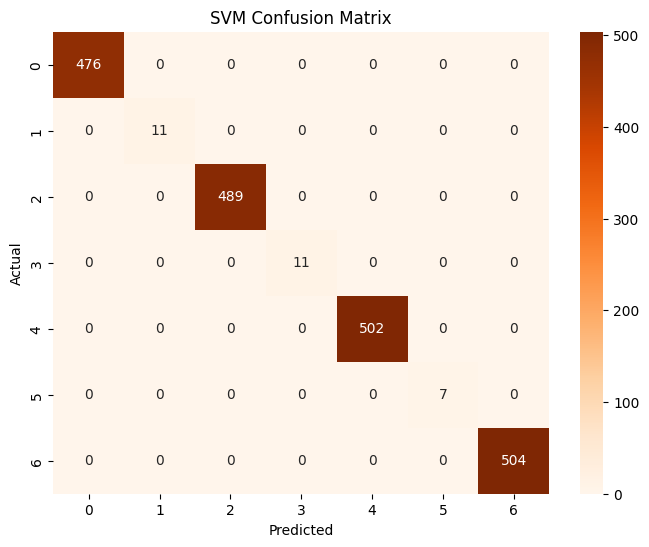

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [13]:
import joblib

joblib.dump(model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully")

Model Saved Successfully
